# Exploración de `data`, `item` y `user` juntos

Este notebook cruza las tres tablas del proyecto a la vez (`data_item_user.csv`, que ya incluye
calificación, película y usuario) para responder una pregunta que ni `data_item.ipynb` ni `user.ipynb`
pueden responder por separado: **¿el tipo de película que se califica se relaciona con quién la califica?**

Concretamente, dos preguntas:

* ¿Hombres y mujeres tienden a calificar géneros distintos?
* ¿La edad se asocia con el tipo de película que se califica?

A diferencia de los otros dos notebooks, aquí la variable de interés no es un solo número por sujeto, sino
**qué proporción de las calificaciones de cada usuario corresponde a cada género** — así que la sección 3
dedica más espacio de lo habitual a justificar esa elección.

## 1. Importación de librerías y datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
data_item_user = pd.read_csv(
    "../../data/processed/data_item_user.csv",
    parse_dates=["datetime"],
    dtype={"zip_code": str},
)

print(f"data_item_user: {data_item_user.shape[0]} filas, {data_item_user.shape[1]} columnas")
print(f"Usuarios distintos: {data_item_user['user_id'].nunique()}")
print(f"Películas distintas: {data_item_user['item_id'].nunique()}")
data_item_user.head()

data_item_user: 99455 filas, 30 columnas
Usuarios distintos: 943
Películas distintas: 1661


,user_id,item_id,rating,timestamp,datetime,title,release_date,unknown,Action,Adventure,...,Mystery,Romance,Sci-Fi,Thriller,War,Western,age,gender,occupation,zip_code
0,1,1,5,874965758,1997-09-22 22:02:38,Toy Story (1995),1995-01-01,0,0,0,...,0,0,0,0,0,0,24,M,technician,85711
1,1,2,3,876893171,1997-10-15 05:26:11,GoldenEye (1995),1995-01-01,0,1,1,...,0,0,0,1,0,0,24,M,technician,85711
2,1,3,4,878542960,1997-11-03 07:42:40,Four Rooms (1995),1995-01-01,0,0,0,...,0,0,0,1,0,0,24,M,technician,85711
3,1,4,3,876893119,1997-10-15 05:25:19,Get Shorty (1995),1995-01-01,0,1,0,...,0,0,0,0,0,0,24,M,technician,85711
4,1,5,3,889751712,1998-03-13 01:15:12,Copycat (1995),1995-01-01,0,0,0,...,0,0,0,1,0,0,24,M,technician,85711


## 2. Validación de la integridad del archivo triple

**Qué se calcula:** al igual que en `data_item.ipynb`, no se dispone aquí de las tres tablas originales
por separado, así que se valida el archivo ya cruzado comprobando que los metadatos de usuario (edad,
género, ocupación, código postal) sean constantes para cada `user_id`, y que los metadatos de película
(título, fecha de estreno, géneros) sean constantes para cada `item_id`.

**Por qué es relevante:** si el cruce triple se hubiera hecho mal (por ejemplo, mezclando la fila de un
usuario con los datos demográficos de otro), aparecería como variación donde no debería haberla.

In [3]:
GENEROS = ["unknown", "Action", "Adventure", "Animation", "Children's", "Comedy", "Crime",
           "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
           "Romance", "Sci-Fi", "Thriller", "War", "Western"]

columnas_usuario = ["age", "gender", "occupation", "zip_code"]
columnas_pelicula = ["title", "release_date"] + GENEROS

variacion_usuario = data_item_user.groupby("user_id")[columnas_usuario].nunique()
variacion_pelicula = data_item_user.groupby("item_id")[columnas_pelicula].nunique()

print(f"Nulos totales: {data_item_user.isnull().sum().sum()}")
print(f"Pares (user_id, item_id) duplicados: "
      f"{data_item_user.duplicated(subset=['user_id', 'item_id']).sum()}")
print(f"Usuarios con metadatos inconsistentes entre filas: {(variacion_usuario > 1).any(axis=1).sum()}"
      f" de {data_item_user['user_id'].nunique()}")
print(f"Películas con metadatos inconsistentes entre filas: {(variacion_pelicula > 1).any(axis=1).sum()}"
      f" de {data_item_user['item_id'].nunique()}")

Nulos totales: 0
Pares (user_id, item_id) duplicados: 0
Usuarios con metadatos inconsistentes entre filas: 0 de 943
Películas con metadatos inconsistentes entre filas: 0 de 1661


**Resultados:** cero nulos, cero pares duplicados, y tanto los 943 usuarios como las 1 661 películas
tienen metadatos perfectamente constantes en todas sus filas. Las cifras (943 usuarios, 99 455
calificaciones) coinciden exactamente con las validadas de forma independiente en `user.ipynb` y en
`data_item.ipynb`, lo que es una comprobación cruzada adicional de que las tres tablas están bien
alineadas entre sí.

**Conclusión:** el archivo es confiable para trabajar directamente sobre él.

## 3. Nota metodológica: la unidad de análisis y la variable de interés

Este notebook combina los dos problemas de unidad de análisis que ya aparecieron por separado en
`user.ipynb` (repetición por usuario) y en `data_item.ipynb` (repetición por película, géneros no
excluyentes). Sobre las 99 455 filas crudas, un mismo usuario aparece decenas o cientos de veces, y cada
fila puede pertenecer a varios géneros a la vez. Cualquier prueba a nivel de fila estaría muy pseudorreplicada
por partida doble.

**La solución adoptada:** para cada usuario se calcula la **proporción de sus propias calificaciones** que
corresponde a cada género (por ejemplo, si el 30 % de las películas que calificó el usuario 7 son de
Acción, ese usuario tiene un valor de 0.30 en la columna `Action`). Esto da una tabla de **943 filas**, una
por usuario, con una columna por género — la unidad de análisis vuelve a ser el usuario, y cada persona
pesa exactamente lo mismo sin importar cuántas calificaciones haya hecho.

Este enfoque tiene un límite que conviene declarar de entrada: para usuarios con muy pocas calificaciones,
la proporción por género es una estimación ruidosa (un solo dato de Terror ya sube esa proporción a 100 %
si es su única calificación en ese género). No se filtra a los usuarios de baja actividad porque el objetivo
aquí es describir a la población de usuarios tal como es, no estimar con precisión el "verdadero" gusto de
cada persona; pero es una limitación real que se retoma en la sección 6.

In [4]:
GENEROS_A_PROBAR = [g for g in GENEROS if g != "unknown"]

perfil_usuario = data_item_user.groupby("user_id")[GENEROS_A_PROBAR].mean()
perfil_usuario["gender"] = data_item_user.groupby("user_id")["gender"].first()
perfil_usuario["age"] = data_item_user.groupby("user_id")["age"].first()
perfil_usuario["n_calificaciones"] = data_item_user.groupby("user_id").size()

# Diccionario donde se guardan los p-valores para corregirlos al final (sección 6)
pruebas = {}

print(f"Perfil de usuarios: {perfil_usuario.shape[0]} filas (una por usuario)")
perfil_usuario[["gender", "age", "n_calificaciones", "Action", "Drama", "Romance"]].head()

Perfil de usuarios: 943 filas (una por usuario)


,gender,age,n_calificaciones,Action,Drama,Romance
user_id,,,,,,
1,M,24,270,0.277778,0.392593,0.159259
2,F,53,60,0.166667,0.550000,0.266667
3,M,23,53,0.264151,0.396226,0.094340
4,M,24,24,0.333333,0.250000,0.125000
5,F,33,174,0.321839,0.155172,0.109195


In [5]:
def cliffs_delta(a, b):
    """Tamaño del efecto no paramétrico. |d| < 0.147 despreciable, < 0.33 pequeño, < 0.474 mediano."""
    u, _ = stats.mannwhitneyu(a, b, alternative="two-sided")
    return 2 * u / (len(a) * len(b)) - 1


def holm(p_valores):
    """Corrección de Holm-Bonferroni para comparaciones múltiples."""
    ordenados = sorted(p_valores.items(), key=lambda par: par[1])
    m = len(ordenados)
    ajustados, maximo_previo = {}, 0.0
    for i, (nombre, p) in enumerate(ordenados):
        maximo_previo = max(maximo_previo, min(1.0, (m - i) * p))
        ajustados[nombre] = maximo_previo
    return ajustados

## 4. Género de la película y género del usuario

**Qué se calcula:** para cada género de película, se compara —con **Mann-Whitney**— la proporción de
calificaciones que le dedican los hombres frente a las mujeres, y el tamaño del efecto (delta de Cliff).

**Hipótesis (por género de película):** H₀: hombres y mujeres dedican, en proporción, la misma parte de
sus calificaciones a ese género. H₁: difiere.

In [6]:
filas_genero = []
hombres = perfil_usuario[perfil_usuario["gender"] == "M"]
mujeres = perfil_usuario[perfil_usuario["gender"] == "F"]

for genero in GENEROS_A_PROBAR:
    h = hombres[genero]
    m = mujeres[genero]
    _, p = stats.mannwhitneyu(h, m, alternative="two-sided")
    delta = cliffs_delta(h, m)
    pruebas[f"MW proporción {genero} ~ género usuario"] = p
    filas_genero.append((genero, h.mean(), m.mean(), p, delta))

tabla_genero_usuario = pd.DataFrame(
    filas_genero,
    columns=["género_película", "proporción_media_hombres", "proporción_media_mujeres", "p", "delta_cliff"],
).sort_values("p").reset_index(drop=True)
tabla_genero_usuario.round(4)

,género_película,proporción_media_hombres,proporción_media_mujeres,p,delta_cliff
0,Romance,0.1936,0.2386,0.0000,-0.3288
1,Sci-Fi,0.1406,0.1016,0.0000,0.3145
2,Action,0.2769,0.2240,0.0000,0.2341
3,Western,0.0147,0.0091,0.0000,0.1907
4,Adventure,0.1375,0.1121,0.0000,0.1939
5,Crime,0.0908,0.0804,0.0001,0.1603
6,Musical,0.0405,0.0498,0.0013,-0.1326
7,Children's,0.0592,0.0751,0.0018,-0.1295
8,Film-Noir,0.0193,0.0162,0.0019,0.1260
9,Drama,0.4054,0.4363,0.0024,-0.1261


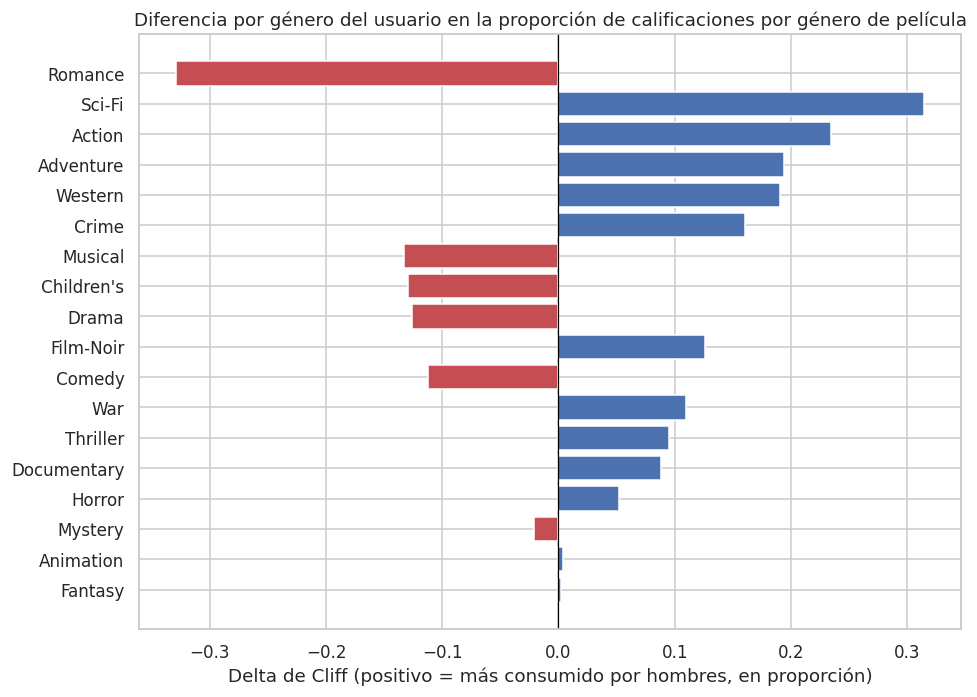

In [7]:
orden = tabla_genero_usuario.reindex(
    tabla_genero_usuario["delta_cliff"].abs().sort_values(ascending=True).index
)["género_película"]

fig, ax = plt.subplots(figsize=(9, 6.5))
y_pos = np.arange(len(orden))
deltas_ordenados = tabla_genero_usuario.set_index("género_película").loc[orden, "delta_cliff"]
colores = ["#4C72B0" if d > 0 else "#C44E52" for d in deltas_ordenados]
ax.barh(y_pos, deltas_ordenados, color=colores)
ax.set_yticks(y_pos)
ax.set_yticklabels(orden)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Delta de Cliff (positivo = más consumido por hombres, en proporción)")
ax.set_title("Diferencia por género del usuario en la proporción de calificaciones por género de película")
fig.tight_layout()
plt.show()

**Resultados (antes de corregir):** las diferencias más marcadas son Romance (mujeres dedican en
promedio el 23.9 % de sus calificaciones a este género, frente al 19.4 % de los hombres; delta = -0.33),
Sci-Fi (14.1 % hombres vs. 10.2 % mujeres; delta = 0.31), Acción (27.7 % vs. 22.4 %; delta = 0.23) y Drama
(40.5 % hombres vs. 43.6 % mujeres; delta = -0.13). Animación y Fantasía no muestran ninguna diferencia
(p > 0.9).

**Conclusión:** hay una diferencia real, aunque de tamaño pequeño a moderado según los estándares
habituales de Cliff, en varios géneros — con el patrón más reconocible en Romance (más mujeres) y en Acción
/Sci-Fi (más hombres). Ningún delta supera 0.33 en valor absoluto, así que ninguna de estas diferencias es
grande: describen una inclinación estadística de la muestra, no una regla que aplique a cualquier persona
concreta.

## 5. Edad y tipo de película

**Qué se calcula:** correlación de **Spearman** entre la edad del usuario y la proporción de sus
calificaciones dedicada a cada género.

**Hipótesis (por género de película):** H₀: ρ = 0 (la edad no se asocia con la proporción dedicada a ese
género).

In [8]:
filas_edad = []
for genero in GENEROS_A_PROBAR:
    rho, p = stats.spearmanr(perfil_usuario["age"], perfil_usuario[genero])
    pruebas[f"Spearman edad ~ proporción {genero}"] = p
    filas_edad.append((genero, rho, p))

tabla_edad_genero = pd.DataFrame(
    filas_edad, columns=["género_película", "rho", "p"]
).sort_values("rho").reset_index(drop=True)
tabla_edad_genero.round(4)

,género_película,rho,p
0,Horror,-0.2589,0.0000
1,Sci-Fi,-0.2484,0.0000
2,Action,-0.2479,0.0000
3,Adventure,-0.2113,0.0000
4,Thriller,-0.1810,0.0000
5,Animation,-0.1791,0.0000
6,Children's,-0.1148,0.0004
7,Comedy,-0.1125,0.0005
8,Fantasy,-0.1057,0.0012
9,Crime,-0.0476,0.1438


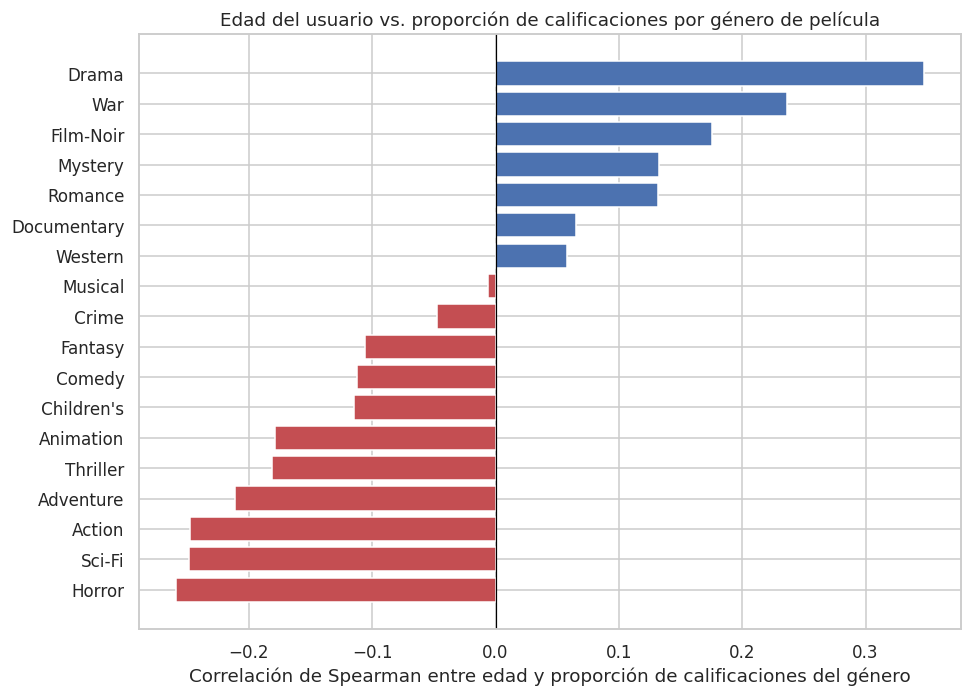

In [9]:
fig, ax = plt.subplots(figsize=(9, 6.5))
colores = ["#4C72B0" if r > 0 else "#C44E52" for r in tabla_edad_genero["rho"]]
ax.barh(tabla_edad_genero["género_película"], tabla_edad_genero["rho"], color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlación de Spearman entre edad y proporción de calificaciones del género")
ax.set_title("Edad del usuario vs. proporción de calificaciones por género de película")
fig.tight_layout()
plt.show()

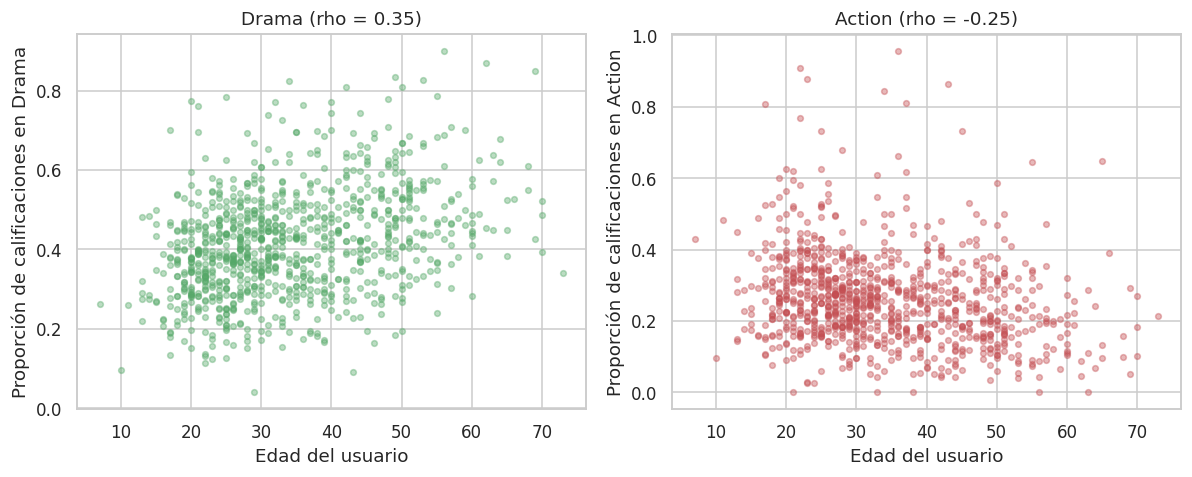

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, genero, color in zip(axes, ["Drama", "Action"], ["#55A868", "#C44E52"]):
    ax.scatter(perfil_usuario["age"], perfil_usuario[genero], s=14, alpha=0.4, color=color)
    rho = tabla_edad_genero.set_index("género_película").loc[genero, "rho"]
    ax.set_xlabel("Edad del usuario")
    ax.set_ylabel(f"Proporción de calificaciones en {genero}")
    ax.set_title(f"{genero} (rho = {rho:.2f})")
fig.tight_layout()
plt.show()

**Resultados (antes de corregir):** las asociaciones más fuertes son Drama (**ρ = 0.347**, positiva: a
mayor edad, mayor proporción de Drama) y Terror (**ρ = -0.259**, negativa: a mayor edad, menor proporción
de Terror), seguidas de Sci-Fi (ρ = -0.248), Acción (ρ = -0.248) y Guerra (ρ = 0.236). Musical, Fantasía y
Crimen no muestran asociación apreciable.

**Conclusión:** aparece un patrón consistente y con sentido narrativo: los usuarios de más edad dedican
proporcionalmente más calificaciones a Drama, Guerra, Cine negro y Misterio, y menos a Terror, Sci-Fi,
Acción y Aventura — géneros que suelen asociarse con un público más joven. Igual que con el género del
usuario, estas son correlaciones de tamaño pequeño a moderado (el mayor |ρ| es 0.35), útiles para describir
una tendencia poblacional, no para predecir el gusto de una persona en particular.

## 6. Corrección por comparaciones múltiples

**Qué se calcula:** el ajuste de **Holm-Bonferroni** sobre los 36 p-valores obtenidos (18 géneros ×
2 preguntas: género del usuario y edad).

**Por qué es relevante:** con 36 pruebas a α = 0.05 sin corregir, la probabilidad de al menos un falso
positivo por azar es prácticamente segura (> 80 %). El ajuste de Holm es indispensable aquí, más incluso
que en los otros dos notebooks del equipo.

In [11]:
ajustados = holm(pruebas)
tabla_pruebas = pd.DataFrame({
    "p_original": pd.Series(pruebas),
    "p_ajustado_holm": pd.Series(ajustados),
})
tabla_pruebas["significativo_5%"] = np.where(tabla_pruebas["p_ajustado_holm"] < 0.05, "sí", "no")
n_significativas = (tabla_pruebas["significativo_5%"] == "sí").sum()
print(f"Pruebas significativas al 5% tras el ajuste: {n_significativas} de {len(tabla_pruebas)}")
tabla_pruebas.sort_values("p_original").round(5)

Pruebas significativas al 5% tras el ajuste: 24 de 36


,p_original,p_ajustado_holm,significativo_5%
Spearman edad ~ proporción Drama,0.00000,0.00000,sí
Spearman edad ~ proporción Horror,0.00000,0.00000,sí
MW proporción Romance ~ género usuario,0.00000,0.00000,sí
Spearman edad ~ proporción Sci-Fi,0.00000,0.00000,sí
Spearman edad ~ proporción Action,0.00000,0.00000,sí
MW proporción Sci-Fi ~ género usuario,0.00000,0.00000,sí
Spearman edad ~ proporción War,0.00000,0.00000,sí
Spearman edad ~ proporción Adventure,0.00000,0.00000,sí
MW proporción Action ~ género usuario,0.00000,0.00000,sí
Spearman edad ~ proporción Thriller,0.00000,0.00000,sí


**Resultados:** 24 de las 36 pruebas siguen siendo significativas al 5 % tras el ajuste. Por género del
usuario sobreviven 10 de 18 géneros (Romance, Sci-Fi, Acción, Western, Aventura, Crimen, Musical, Niños,
Cine negro y Drama); no sobreviven Comedia, Guerra, Documental, Thriller, Terror, Misterio, Animación y
Fantasía, que ya eran débiles o límite sin corregir. Por edad sobreviven 14 de 18 (todos menos Documental,
Western, Crimen y Musical). Los patrones más fuertes de ambas secciones (Romance/Acción/Sci-Fi por género
del usuario; Drama/Terror/Acción/Sci-Fi por edad) se mantienen firmes con amplio margen.

**Conclusión:** el ajuste no cambia la historia principal, pero sí depura varios resultados limítrofes —
sobre todo por el lado del género del usuario, donde casi la mitad de los géneros pierde significancia al
corregir— que, sin ajustar, se habrían presentado como hallazgos cuando en realidad eran ruido esperable al
correr 36 pruebas a la vez.

## 7. Conclusiones y limitaciones

### Conclusiones

1. **El cruce triple es íntegro:** 943 usuarios y 1 661 películas con metadatos constantes, cifras que
   coinciden con las validadas por separado en `user.ipynb` y `data_item.ipynb`.
2. **El género del usuario se asocia con qué se califica, no solo con cuánto:** las mujeres de la muestra
   dedican proporcionalmente más calificaciones a Romance y Drama; los hombres, a Acción y Sci-Fi. Los
   efectos son de tamaño pequeño a moderado.
3. **La edad se asocia con un desplazamiento hacia géneros "más adultos":** más Drama, Guerra y Misterio, y
   menos Terror, Acción y Sci-Fi a medida que aumenta la edad.
4. **Ambos patrones son estadísticamente robustos** incluso después de corregir por las 36 comparaciones
   realizadas, aunque una parte relevante de las asociaciones más débiles no lo es.

### Limitaciones

* **Proporciones ruidosas para usuarios poco activos:** el diseño de la sección 3 no filtra por actividad
  mínima, así que la proporción por género de los usuarios con pocas calificaciones tiene más varianza que
  la de los usuarios muy activos — no se distingue eso en las pruebas.
* **Género y edad probablemente no son independientes entre sí ni de la ocupación:** este notebook no
  controla el uno por el otro (por ejemplo, si la diferencia de edad en Acción se debe en parte a que los
  hombres de la muestra son en promedio más jóvenes). Haría falta un modelo multivariable para separar esos
  efectos, fuera del alcance de este análisis descriptivo.
* **Géneros de película no excluyentes:** las proporciones de un mismo usuario no suman 1 porque una
  película puede contar para varios géneros a la vez; esto no invalida las comparaciones (cada género se
  prueba por separado), pero sí impide interpretar las proporciones como una distribución completa de
  preferencias.
* **Muestra y periodo:** los mismos límites de `user.ipynb` — usuarios de MovieLens 1997-1998,
  auto-seleccionados y con al menos 19 calificaciones cada uno; los resultados no se extrapolan sin más a
  otras plataformas o épocas.